<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Fashion_MNIST_Feedforward_NN_Assignment_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion MNIST Image Classification with a Feedforward Neural Network

This notebook implements an image classification pipeline using **Fashion MNIST** and a simple **feedforward neural network (MLP)** in **TensorFlow/Keras**.

**Assignment coverage**
- dataset loading and visualization
- image normalization
- feedforward neural network design
- training and validation monitoring
- evaluation with accuracy, precision, recall, F1-score
- confusion matrix and classification report
- comparison with a deeper model
- optional data augmentation discussion


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [4]:
# Load Fashion MNIST
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Training shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Training shape: (60000, 28, 28) (60000,)
Test shape: (10000, 28, 28) (10000,)


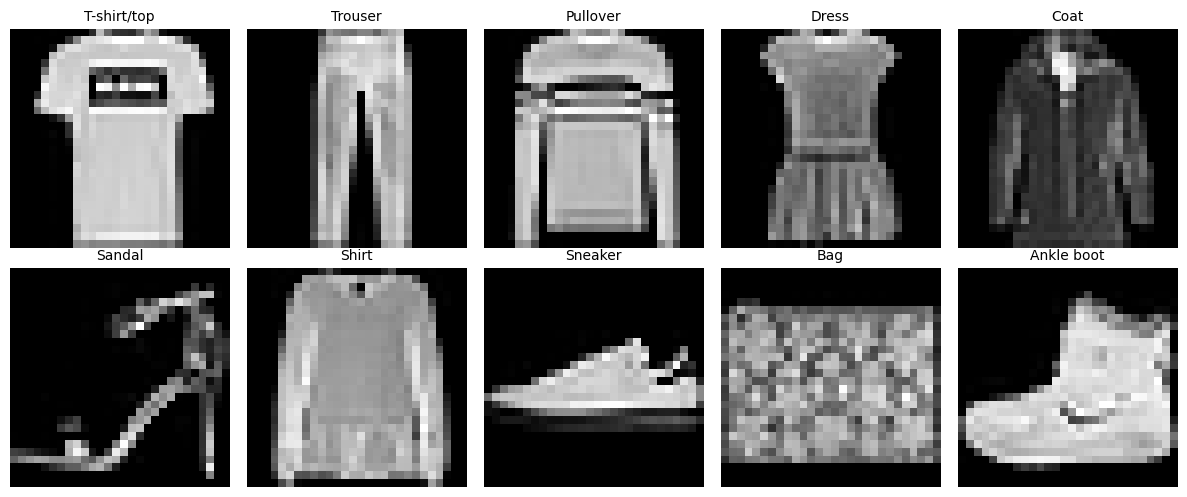

In [5]:
# Visualize one sample from each class
plt.figure(figsize=(12, 5))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(class_names[i], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
# Normalize images to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Keep integer labels for reporting
y_train_int = y_train.copy()
y_test_int = y_test.copy()

# One-hot encode targets for neural network training
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Create validation split from training data
X_train_split, X_val, y_train_split, y_val, y_train_int_split, y_val_int = train_test_split(
    X_train, y_train_cat, y_train_int, test_size=0.1, random_state=42, stratify=y_train_int
)

print("Train split:", X_train_split.shape)
print("Validation split:", X_val.shape)


Train split: (54000, 28, 28)
Validation split: (6000, 28, 28)


In [7]:
# Baseline feedforward neural network
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=64,
    verbose=1
)


Epoch 1/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8001 - loss: 0.5556 - val_accuracy: 0.8538 - val_loss: 0.3972
Epoch 2/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8494 - loss: 0.4115 - val_accuracy: 0.8755 - val_loss: 0.3388
Epoch 3/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8632 - loss: 0.3743 - val_accuracy: 0.8793 - val_loss: 0.3299
Epoch 4/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8721 - loss: 0.3492 - val_accuracy: 0.8785 - val_loss: 0.3327
Epoch 5/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8769 - loss: 0.3338 - val_accuracy: 0.8888 - val_loss: 0.3070
Epoch 6/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8816 - loss: 0.3198 - val_accuracy: 0.8872 - val_loss: 0.3034
Epoch 7/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8861 - loss: 0.3068 - val_accuracy: 0.8870 - val_loss: 0.3120
Epoch 8/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8864 - loss: 0.3035 - val_accuracy

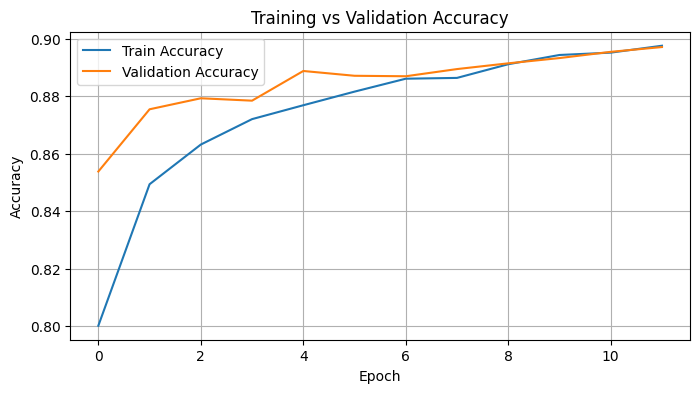

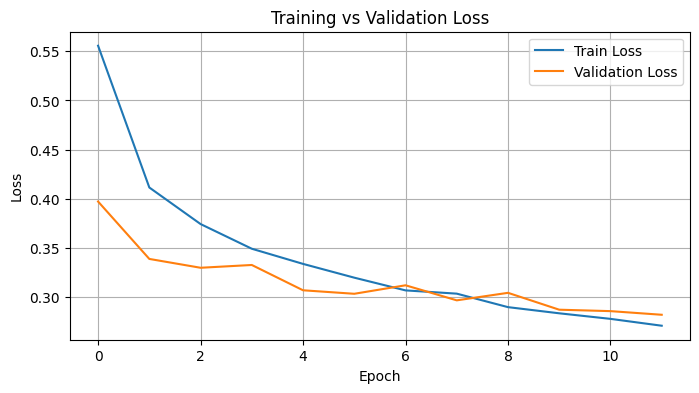

In [9]:
# Plot training history
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(8, 4))
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(y_test_int, y_pred, average='weighted')

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_int, y_pred, target_names=class_names))


Test Loss: 0.3273
Test Accuracy: 0.8860
Weighted Precision: 0.8859
Weighted Recall: 0.8860
Weighted F1-score: 0.8856

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.77      0.82      0.80      1000
       Dress       0.88      0.91      0.89      1000
        Coat       0.82      0.78      0.80      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.73      0.67      0.70      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.94      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



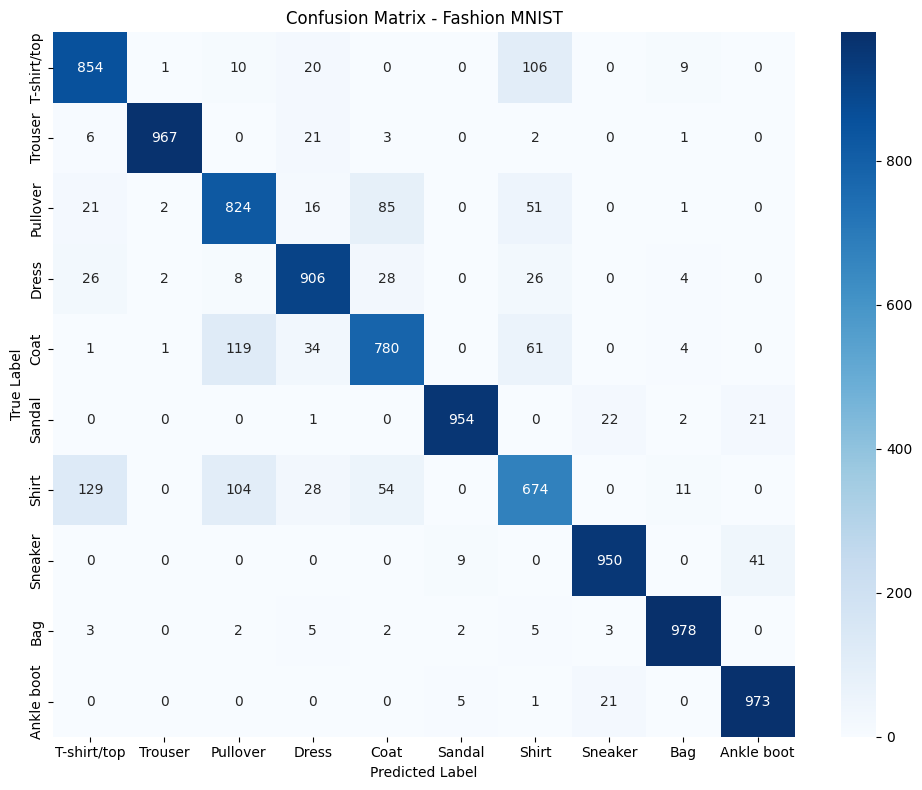

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test_int, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fashion MNIST')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


## Model Improvement Experiment

.  
The next cell trains a slightly deeper model for comparison.


In [12]:
improved_model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_history = improved_model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=64,
    verbose=1
)

improved_test_loss, improved_test_acc = improved_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Improved Model Test Accuracy: {improved_test_acc:.4f}")


Epoch 1/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.7921 - loss: 0.5721 - val_accuracy: 0.8578 - val_loss: 0.3830
Epoch 2/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8432 - loss: 0.4288 - val_accuracy: 0.8667 - val_loss: 0.3664
Epoch 3/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8576 - loss: 0.3891 - val_accuracy: 0.8717 - val_loss: 0.3504
Epoch 4/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8645 - loss: 0.3706 - val_accuracy: 0.8828 - val_loss: 0.3209
Epoch 5/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8698 - loss: 0.3535 - val_accuracy: 0.8785 - val_loss: 0.3212
Epoch 6/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8743 - loss: 0.3403 - val_accuracy: 0.8827 - val_loss: 0.3215
Epoch 7/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8793 - loss: 0.3273 - val_accuracy: 0.8868 - val_loss: 0.3093
Epoch 8/12
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8818 - loss: 0.3192 - 

## Practical Application Discussion

A trained Fashion MNIST classifier could support:
- **fashion retail cataloging** by auto-tagging clothing images,
- **inventory organization** in e-commerce systems,
- **visual search pipelines** where products are grouped by item type.

### Deployment considerations
- scalability for large image streams,
- inference latency for near real-time use,
- retraining when new styles appear,
- integration with mobile or cloud-based product databases.

## Conclusion

This notebook demonstrates that even a simple feedforward neural network can classify fashion images effectively.  
A deeper architecture usually improves accuracy, but CNNs would typically outperform MLPs because they better capture spatial image patterns.
